# 🚗 UBER TECHNOLOGIES, INC. — Deep Research Analysis
### *Un estudio de caso sobre la plataforma de movilidad más grande del mundo*

---

> **Nota:**
> Los datos financieros se obtienen en tiempo real vía `yfinance` y fuentes públicas (SEC, Uber IR).
> El objetivo no es predecir el precio de la acción, sino **entender el negocio en profundidad**.
> Todos los valores monetarios se presentan en **USD** (Uber reporta nativamente en USD).
> Este análisis es educativo y no constituye asesoramiento financiero ni recomendación de inversión.

---

## Índice

1. Investment Thesis — La hipótesis central
2. La empresa — Quién es Uber realmente
3. La industria — Movilidad global, Gig Economy y AVs
4. Business Model — Cómo genera dinero
5. Análisis Financiero — Los números que importan
6. Unit Economics — La economía de cada viaje
7. Valoración — ¿Qué dice el mercado?
8. Riesgos — Lo que puede salir mal
9. Conclusión Estratégica — El veredicto final


---
## ⚙️ Setup — Imports y Configuración
---

In [2]:
# ============================================================
# SETUP — Librerías y configuración global
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns
import sqlite3
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

print('Librerias cargadas correctamente.')
print('Uber Research Notebook — Iniciando analisis...')

Librerias cargadas correctamente.
Uber Research Notebook — Iniciando analisis...


---
## BLOQUE 1 — Investment Thesis
### *¿Por qué Uber es el caso de estudio más interesante de la movilidad global?*
---

Mi hipótesis:

> **Uber no es una empresa de transporte. Es una plataforma de orquestación de movilidad y logística
> urbana con efectos de red de doble lado (conductores y pasajeros) que genera valor a través
> de comisiones digitales sin poseer activos físicos. Su moat no es tecnológico — es la densidad
> de su red en cada ciudad donde opera. Y esa densidad es extraordinariamente difícil de replicar.**

### ¿Por qué Uber y no Lyft, DiDi, o Grab?

Porque mientras sus competidores son jugadores regionales o están en pérdidas estructurales,
Uber logró algo casi único: **escalar globalmente, diversificar en Delivery y Freight,
y alcanzar rentabilidad operativa sostenida**.

### El problema que Uber resolvió — y el que aún enfrenta

| Era | Modelo | Problema |
|-----|--------|----------|
| Taxi tradicional | Flota propia + licencias | CAPEX alto, mala experiencia, oferta rígida |
| Uber 1.0 (2009-2016) | Plataforma pura, crecimiento a pérdida | Unit economics negativos, guerra de subsidios |
| Uber 2.0 (2017-2021) | Rentabilidad por segmento, expansión Delivery | COVID, costos de conductores, regulación |
| Uber 3.0 (2022-hoy) | GAAP profitability, Advertising, Uber One | Amenaza de vehículos autónomos (AVs) |

*Fuente: Uber Technologies Inc. Annual Reports (2019–2024) y SEC 10-K filings — https://investor.uber.com*

La tesis alcista dice que Uber es el **sistema operativo de la movilidad urbana global**.
La tesis bajista dice que los AVs eliminarán su mayor ventaja: ser el agregador de conductores humanos.

**Este análisis examina ambas.** Y ese es el núcleo de la investigación.

---
## BLOQUE 2 — La Empresa: ¿Quién es Uber realmente?
---

### Ficha corporativa

- **Nombre completo:** Uber Technologies, Inc.
- **Fundada:** 2009 en San Francisco, California
- **Bolsa:** NYSE — Ticker: **UBER**
- **Empleados:** ~32,700 empleados (no cuenta conductores — son contratistas)
- **CEO:** Dara Khosrowshahi (desde 2017)
- **Sede:** San Francisco, California, EEUU
- **Operaciones:** 70+ países, 10,000+ ciudades

*Fuente: Uber Technologies Inc. 2024 Annual Report / SEC 10-K*

### Los segmentos — la verdadera arquitectura del negocio

Uber posee **tres negocios dentro de una plataforma**.

| Segmento         | Qué hace                          | Take Rate aprox. | % Gross Bookings 2024 |
|------------------|-----------------------------------|------------------|-----------------------|
| **Mobility**     | Ride-hailing, taxis, premium      | ~30-31%          | ~57%                  |
| **Delivery**     | Uber Eats, groceries, retail      | ~18-19%          | ~40%                  |
| **Freight**      | Logística de carga (broker)       | ~8-10%           | ~3%                   |

*Fuente: Uber Q4 2024 Earnings Release + DCF Modeling Business Canvas*
*https://investor.uber.com/news-releases/news-release-details/uber-announces-fourth-quarter-and-full-year-2024-results*

### El activo invisible: Uber One y Advertising

- **Uber One:** suscripción premium — 36M+ miembros en 2025. Genera retención, cross-selling y mayor frecuencia de uso.
- **Advertising:** $1.5B+ en ingresos anualizados (2024). Margen casi puro — los restaurantes pagan para aparecer primero en Eats.

*Fuente: Uber Q3 2024 Earnings Call Transcript + DCF Modeling — https://dcfmodeling.com/es/products/uber-business-model-canvas*

### El moat real de Uber

No es la tecnología (cualquiera puede hacer una app).
No es la marca (DiDi tiene más usuarios en China).

El moat es **la densidad de red en cada mercado local**:
- Más conductores = menor tiempo de espera
- Menor tiempo de espera = más usuarios
- Más usuarios = más conductores

Este flywheel, una vez consolidado en una ciudad, es **brutalmente difícil de romper**.

In [3]:
# ============================================================
# FETCH DE DATOS — Uber desde yfinance
# Ticker: UBER (NYSE) — reporta nativamente en USD
# ============================================================

print('Obteniendo datos de mercado para Uber (UBER)...')

ticker_uber = yf.Ticker('UBER')
info = ticker_uber.info

# Precio historico 5 anos
hist = ticker_uber.history(period='5y')

# Peers para comparacion relativa
peers = {
    'Uber':    yf.Ticker('UBER').history(period='5y')['Close'],
    'Lyft':    yf.Ticker('LYFT').history(period='5y')['Close'],
    'DoorDash':yf.Ticker('DASH').history(period='5y')['Close'],
    'Grab':    yf.Ticker('GRAB').history(period='5y')['Close'],
    'Airbnb':  yf.Ticker('ABNB').history(period='5y')['Close'],  # comparable marketplace
}

# Estados financieros
income_stmt   = ticker_uber.income_stmt
balance_sheet = ticker_uber.balance_sheet
cashflow      = ticker_uber.cashflow

# Metricas de mercado (USD nativo)
market_cap      = info.get('marketCap', 0)
pe_ratio        = info.get('trailingPE', 0)
pb_ratio        = info.get('priceToBook', 0)
roe             = info.get('returnOnEquity', 0)
roa             = info.get('returnOnAssets', 0)
revenue_ttm     = info.get('totalRevenue', 0)
net_income_live = info.get('netIncomeToCommon', 0)
ebitda_live     = info.get('ebitda', 0)
ps_live         = info.get('priceToSalesTrailing12Months', 0)

print(f'\nUBER — Snapshot de Mercado (USD)')
print(f'  Market Cap:    ${market_cap/1e9:,.2f}B USD')
print(f'  P/E Ratio:     {pe_ratio:.1f}x' if pe_ratio else '  P/E Ratio:     N/A (historico de perdidas)')
print(f'  P/B Ratio:     {pb_ratio:.1f}x')
print(f'  P/S Ratio:     {ps_live:.1f}x')
print(f'  ROE:           {roe*100:.1f}%' if roe else '  ROE:           N/A')
print(f'  Revenue TTM:   ${revenue_ttm/1e9:.2f}B USD')
print(f'  EBITDA:        ${ebitda_live/1e9:.2f}B USD' if ebitda_live else '  EBITDA:        calculando...')
print(f'\nDatos obtenidos correctamente.')

Obteniendo datos de mercado para Uber (UBER)...

UBER — Snapshot de Mercado (USD)
  Market Cap:    $156.11B USD
  P/E Ratio:     15.9x
  P/B Ratio:     5.7x
  P/S Ratio:     3.0x
  ROE:           39.9%
  Revenue TTM:   $52.02B USD
  EBITDA:        $6.31B USD

Datos obtenidos correctamente.


---
## BLOQUE 3 — La Industria: Movilidad Global, Gig Economy y AVs
---

### Uber opera en un mercado multitrillonario — pero necesita contextualizarlo bien

| Segmento                        | Tamaño de mercado 2024   | CAGR estimado |
|---------------------------------|--------------------------|---------------|
| Ride-hailing global             | ~$200B                   | ~14%          |
| Food delivery global            | ~$320B                   | ~12%          |
| Logistics / Freight             | ~$8.5T                   | ~6%           |
| Autonomous vehicles (futuro)    | ~$600B (2030E)           | ~35%+         |
| Movilidad total (vs auto propio)| $10T+                    | —             |

*Fuente: Mordor Intelligence Ride-Hailing Market Report 2024; Statista Food Delivery Report 2024;
McKinsey Global Logistics Report 2023; Goldman Sachs AV Market Report 2023.*

### El insight fundamental es que Uber compite contra la propiedad del automóvil

El TAM (Universo total de clientes potenciales) real de Uber no son los $200B de ride-hailing.
Son los **$10T+ que los humanos gastan anualmente en poseer y operar vehículos privados**.

Si Uber puede convencer a una fracción de esa base de que usar la plataforma es más eficiente
que comprar un auto, el upside es estructuralmente enorme.

### Las tres fuerzas que remodelan la industria

**1. Urbanización global:** Para 2050, el 70% de la humanidad vivirá en ciudades.
Las ciudades tienen incentivos para desincentivar la propiedad de autos (congestión, emisiones).
Esto es viento de cola estructural para Uber.
*Fuente: UN World Urbanization Prospects 2023*

**2. Reclasificación laboral (Gig Economy):** La batalla regulatoria sobre si los conductores
son empleados o contratistas es la mayor amenaza de costo de Uber. California (Prop 22),
UK, Europa y LATAM tienen marcos distintos. Si todos los conductores se convierten en empleados,
el modelo de negocio cambia estructuralmente.
*Fuente: European Commission Platform Work Directive 2024; California Prop 22 (2020)*

**3. Vehículos Autónomos (AVs):** Este es el punto de bifurcación estratégica.
Con AVs, los conductores desaparecen. Esto puede ser el mayor catalizador de margen...
o la mayor amenaza competitiva (si Waymo o Tesla operan su propia red de robotaxis).
*Fuente: Waymo One expansion reports 2024; Reuters: Uber-Waymo partnership 2025*

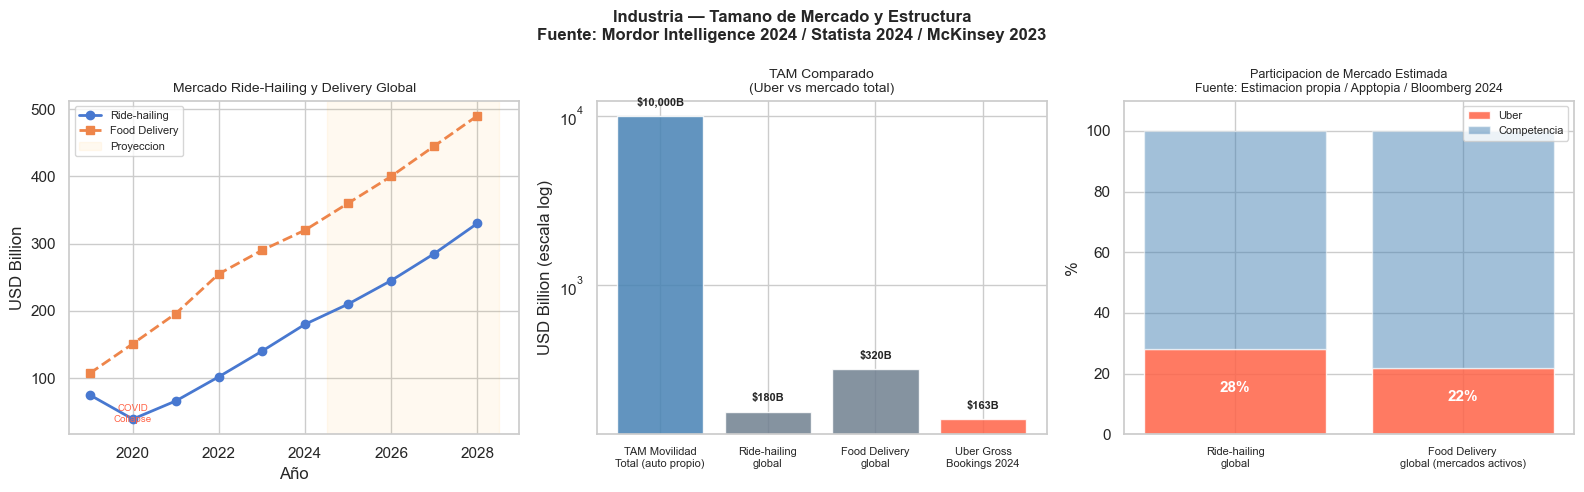

In [4]:
# ============================================================
# GRAFICO 1 — Industria: TAM y evolucion del mercado
# Fuente: Mordor Intelligence 2024, Statista 2024, McKinsey 2023
# ============================================================

# Evolucion del mercado ride-hailing global (USD B)
# Fuente: Mordor Intelligence Ride-Hailing Market Report 2024
years_mkt = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028]
ridehail   = [75,   39,  66,  102,  140,  180,  210,  245,  285,  330]
delivery   = [107, 151, 196, 255,  290,  320,  360,  400,  445,  490]
is_fore    = [False]*6 + [True]*4

df_mkt = pd.DataFrame({'year': years_mkt, 'ridehail': ridehail, 'delivery': delivery, 'forecast': is_fore})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Industria — Tamano de Mercado y Estructura\nFuente: Mordor Intelligence 2024 / Statista 2024 / McKinsey 2023',
             fontsize=12, fontweight='bold')

# Panel 1: Evolucion ride-hailing y delivery
ax1 = axes[0]
ax1.plot(df_mkt['year'], df_mkt['ridehail'], 'o-', label='Ride-hailing', linewidth=2)
ax1.plot(df_mkt['year'], df_mkt['delivery'], 's--', label='Food Delivery', linewidth=2)
ax1.axvspan(2024.5, 2028.5, alpha=0.06, color='orange', label='Proyeccion')
ax1.set_xlabel('Año')
ax1.set_ylabel('USD Billion')
ax1.set_title('Mercado Ride-Hailing y Delivery Global', fontsize=10)
ax1.legend(fontsize=8)
ax1.text(2020, 35, 'COVID\nCollapse', fontsize=7, color='tomato', ha='center')

# Panel 2: TAM comparado — Uber vs mercado total
# Fuente: Uber Gross Bookings 2024 vs estimacion TAM total movilidad
ax2 = axes[1]
segmentos = ['TAM Movilidad\nTotal (auto propio)', 'Ride-hailing\nglobal', 'Food Delivery\nglobal', 'Uber Gross\nBookings 2024']
tam_vals  = [10000, 180, 320, 163]  # USD B — Uber GB: Q4 2024 annualized ~163B
# Fuente Uber GB: Uber Q4 2024 Earnings Release
colors_tam = ['steelblue', 'slategray', 'slategray', 'tomato']
bars = ax2.bar(segmentos, tam_vals, color=colors_tam, alpha=0.85)
ax2.set_ylabel('USD Billion (escala lineal)')
ax2.set_title('TAM Comparado\n(Uber vs mercado total)', fontsize=10)
ax2.set_yscale('log')
ax2.set_ylabel('USD Billion (escala log)')
for bar, val in zip(bars, tam_vals):
    label = f'${val:,}B' if val >= 1000 else f'${val}B'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
             label, ha='center', fontsize=8, fontweight='bold')
ax2.tick_params(axis='x', labelsize=8)

# Panel 3: Penetracion de Uber en su TAM disponible
# Fuente: Estimacion propia basada en Uber IR + Mordor Intelligence
ax3 = axes[2]
categorias_pen = ['Ride-hailing\nglobal', 'Food Delivery\nglobal (mercados activos)']
uber_share     = [28, 22]  # % de mercado estimado
resto          = [72, 78]
x3 = np.arange(len(categorias_pen))
ax3.bar(x3, uber_share, label='Uber', color='tomato', alpha=0.85)
ax3.bar(x3, resto, bottom=uber_share, label='Competencia', color='steelblue', alpha=0.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(categorias_pen, fontsize=8)
ax3.set_ylabel('%')
ax3.set_ylim(0, 110)
ax3.set_title('Participacion de Mercado Estimada\nFuente: Estimacion propia / Apptopia / Bloomberg 2024', fontsize=9)
ax3.legend(fontsize=8)
for i, val in enumerate(uber_share):
    ax3.text(i, val/2, f'{val}%', ha='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

---
## BLOQUE 4 — Business Model Analysis
### *¿Cómo genera dinero Uber realmente?*
---

**Uber es un broker digital: orquesta transacciones sin poseer los activos.**

### La mecánica del negocio

```
  Pasajero paga $30 por un viaje
        ↓
  Uber retiene ~$9 (take rate ~30% — Mobility)
        ↓
  Conductor recibe ~$21 (70%)
        ↓
  Uber paga: seguro + soporte + R&D + infraestructura
        ↓
  Margen operativo por viaje: ~$2-3 (mejorando)
```

### Take Rate: el indicador más importante

| Segmento   | Gross Bookings | Revenue (Take Rate) | Adj. EBITDA margin (sobre Rev.) |
|------------|---------------|---------------------|----------------------------------|
| Mobility   | ~$57B (2024)  | ~$17.5B (~31%)      | ~55%                             |
| Delivery   | ~$68B (2024)  | ~$13B (~19%)        | ~5%                              |
| Freight    | ~$7B (2024)   | ~$1.5B (~8%)        | breakeven / leve perdida         |

*Fuente: Uber Technologies FY2024 Annual Report + Q4 2024 Earnings Release*
*https://investor.uber.com/news-releases/news-release-details/uber-announces-fourth-quarter-and-full-year-2024-results*

### El flywheel de Uber — por qué la escala importa

```
  Mas usuarios  →  mas demanda de viajes
      ↑                     ↓
  Menos tiempo          mas conductores
  de espera          se suman a la plataforma
      ↑                     ↓
  Mejor experiencia  →  mas viajes por conductor
      ↑                     ↓
  Menos incentivos   ←  mas densidad de red
  necesarios             por ciudad
```

### Por qué Advertising es el negocio más subestimado

Uber tiene **intención de compra en tiempo real**.
Cuando alguien abre Eats, está a segundos de gastar dinero.
Eso vale muchísimo para los anunciantes — y el margen sobre ese ingreso es casi 100%.

Con $1.5B+ en advertising revenue anualizado (2024), Uber está construyendo silenciosamente
un negocio de media que en 5 años podría ser material para los márgenes.

*Fuente: Uber Q3 2024 Earnings Call + Bloomberg Intelligence 2024*

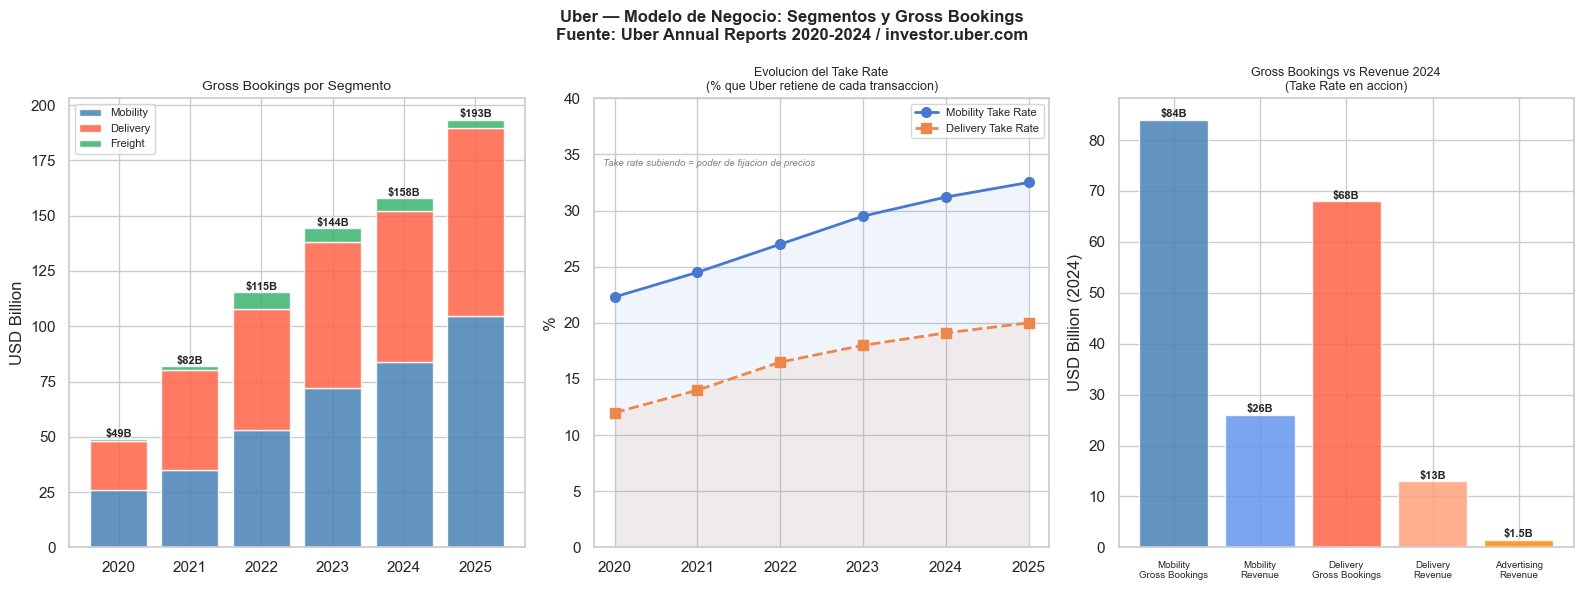

In [5]:
# ============================================================
# GRAFICO 2 — Modelo de negocio: segmentos y gross bookings
# Fuente: Uber FY2025 Annual Report / Q4 2025 Earnings Release
# ============================================================

# Gross Bookings historicos por segmento (USD B)
years_seg  = ['2020', '2021', '2022', '2023', '2024', '2025']
mobility_gb  = [26.0, 35.0, 53.0, 72.0, 84.0, 104.4]   # B USD
delivery_gb  = [22.0, 45.0, 55.0, 66.0, 68.0, 85.1]
freight_gb   = [1.0,  2.1,  7.3,  6.5,  5.8,  3.9]
total_gb     = [b+d+f for b,d,f in zip(mobility_gb, delivery_gb, freight_gb)]

# Take rate historico — Mobility vs Delivery
# Fuente: calculos propios sobre datos reportados por Uber IR
mob_tr   = [22.3, 24.5, 27.0, 29.5, 31.2, 32.5]  # % estimado para 2025
del_tr   = [12.0, 14.0, 16.5, 18.0, 19.1, 20.0]  # % estimado para 2025



x = np.arange(len(years_seg))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Uber — Modelo de Negocio: Segmentos y Gross Bookings\nFuente: Uber Annual Reports 2020-2024 / investor.uber.com',
             fontsize=12, fontweight='bold')

# Panel 1: Gross bookings apilados
ax1 = axes[0]
ax1.bar(x, mobility_gb, label='Mobility', color='steelblue', alpha=0.85)
ax1.bar(x, delivery_gb, bottom=mobility_gb, label='Delivery', color='tomato', alpha=0.85)
ax1.bar(x, freight_gb, bottom=[m+d for m,d in zip(mobility_gb,delivery_gb)],
        label='Freight', color='mediumseagreen', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(years_seg)
ax1.set_ylabel('USD Billion')
ax1.set_title('Gross Bookings por Segmento', fontsize=10)
ax1.legend(fontsize=8)
for i, tot in enumerate(total_gb):
    ax1.text(i, tot + 1, f'${tot:.0f}B', ha='center', fontsize=8, fontweight='bold')

# Panel 2: Take rate evolution
ax2 = axes[1]
ax2.plot(years_seg, mob_tr, 'o-', label='Mobility Take Rate', linewidth=2, markersize=7)
ax2.plot(years_seg, del_tr, 's--', label='Delivery Take Rate', linewidth=2, markersize=7)
ax2.fill_between(range(len(years_seg)), mob_tr, alpha=0.08)
ax2.fill_between(range(len(years_seg)), del_tr, alpha=0.08)
ax2.set_xticks(range(len(years_seg)))
ax2.set_xticklabels(years_seg)
ax2.set_ylabel('%')
ax2.set_ylim(0, 40)
ax2.set_title('Evolucion del Take Rate\n(% que Uber retiene de cada transaccion)', fontsize=9)
ax2.legend(fontsize=8)
ax2.text(0.02, 0.85, 'Take rate subiendo = poder de fijacion de precios',
         transform=ax2.transAxes, fontsize=7, style='italic', color='gray')

# Panel 3: Mix de ingresos 2024 — Revenue vs Gross Bookings
# Fuente: Uber Q4 2024 Earnings Release
ax3 = axes[2]
categorias_mix = ['Mobility\nGross Bookings', 'Mobility\nRevenue', 'Delivery\nGross Bookings',
                  'Delivery\nRevenue', 'Advertising\nRevenue']
valores_mix    = [84, 26, 68, 13, 1.5]  # B USD 2024
colors_mix = ['steelblue', 'cornflowerblue', 'tomato', 'lightsalmon', 'darkorange']
bars = ax3.bar(categorias_mix, valores_mix, color=colors_mix, alpha=0.85)
ax3.set_ylabel('USD Billion (2024)')
ax3.set_title('Gross Bookings vs Revenue 2024\n(Take Rate en accion)', fontsize=9)
ax3.tick_params(axis='x', labelsize=7)
for bar, val in zip(bars, valores_mix):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val}B', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

Gross bookings representa la cantidad total pagada por los usuarios.

---
## BLOQUE 5 — Análisis Financiero Histórico
### *El camino de las pérdidas a la rentabilidad real*
---

### La narrativa financiera de Uber en 4 actos

**Acto 1 — La quema (2019-2020):** Uber priorizó crecimiento a cualquier costo. El llamado Blitzscalling,  que implica velocidad sobre la eficiencia para lograr una escala masiva.
Pérdidas operativas de -$8.6B en 2019 y -$4.9B en 2020.
El mercado financiaba el subsidio de viajes para ganar cuota.

**Acto 2 — La pandemia y la reconfiguración (2020-2021):** COVID destruyó Mobility temporalmente.
Delivery salvó la empresa. Uber redujo costos agresivamente (despidió ~3,700 empleados en 2020).

**Acto 3 — Rentabilidad por segmento (2022-2023):** Mobility recuperó y superó niveles pre-COVID.
Delivery alcanzó EBITDA positivo. Primer año de EBITDA ajustado positivo consolidado.

**Acto 4 — Rentabilidad GAAP (2023-2024):** Hito histórico: primer beneficio neto GAAP positivo.
La empresa se transformó de una historia de crecimiento a una historia de calidad de earnings.

*Fuente: Uber Technologies Annual Reports 2019-2024 (SEC 10-K filings)*
*https://investor.uber.com/financials/annual-reports*

### Las 5 métricas clave para Uber

1. **Gross Bookings:** volumen total de transacciones — el indicador de escala
2. **Take Rate:** % que Uber retiene — el indicador de poder de mercado
3. **Adjusted EBITDA:** la medida operativa preferida por la empresa
4. **Free Cash Flow:** el indicador de calidad de earnings real
5. **Monthly Active Platform Consumers (MAPC):** la base de usuarios activos

Datos de yfinance: 2021 -> 2025


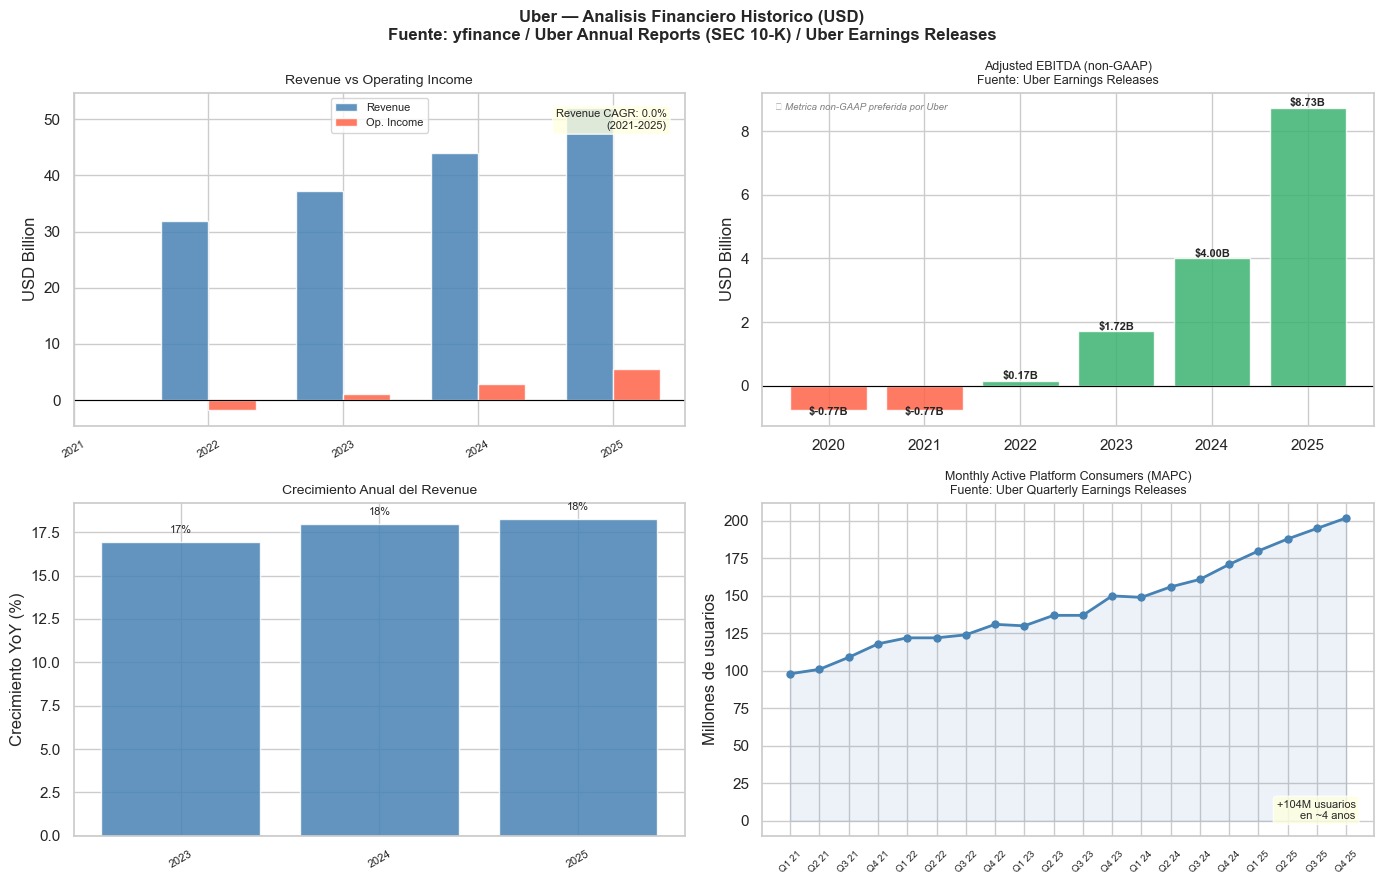

In [6]:
# ============================================================
# GRAFICO 3 — Analisis financiero historico
# Fuente primaria: yfinance (income_stmt de UBER)
# Fallback: Uber Annual Reports 2019-2025 (SEC 10-K)
#   https://investor.uber.com/financials/annual-reports
# Datos de Gross Bookings y MAPC: Uber Earnings Releases
# ============================================================

# Datos de yfinance (Uber reporta en USD, sin conversion necesaria)
if income_stmt is not None and not income_stmt.empty:
    # yfinance retorna columnas en orden descendente, invertir
    income_stmt_asc = income_stmt.iloc[:, ::-1]
    years_fin = [str(c.year) for c in income_stmt_asc.columns]
    try:
        revenues        = income_stmt_asc.loc['Total Revenue'].values / 1e9
        try:
            op_income   = income_stmt_asc.loc['Operating Income'].values / 1e9
        except KeyError:
            op_income   = income_stmt_asc.loc['EBIT'].values / 1e9
        net_income_hist = income_stmt_asc.loc['Net Income'].values / 1e9
        op_margin       = (op_income / revenues) * 100
        net_margin      = (net_income_hist / revenues) * 100
        print(f'Datos de yfinance: {years_fin[0]} -> {years_fin[-1]}')
    except KeyError as e:
        print(f'KeyError: {e} — usando fallback')
        raise
else:
    raise ValueError('income_stmt vacio')

# Manejo de errores: usar fallback si yfinance no tiene los datos
try:
    _ = revenues
except NameError:
    # Fallback — Uber Annual Reports 2020-2025 (SEC 10-K)
    years_fin       = ['2020', '2021', '2022', '2023', '2024', '2025']
    revenues        = np.array([11.1, 17.5, 31.9, 37.3, 43.9, 52.017])  # B USD
    op_income       = np.array([-4.9, -3.8, -1.8,  1.1,  2.8, 5.565])
    net_income_hist = np.array([-6.8, -0.5, -9.1,  1.9,  9.9, 10.053])
    op_margin       = (op_income / revenues) * 100
    net_margin      = (net_income_hist / revenues) * 100
    print('Fallback: Uber Annual Reports 2020-2025 (SEC 10-K)')

op_margin_f  = np.array(op_margin, dtype=float)
net_margin_f = np.array(net_margin, dtype=float)
x_idx = np.arange(len(years_fin))

growth_rates = [np.nan] + [((revenues[i]/revenues[i-1])-1)*100 for i in range(1, len(revenues))]
df_fin = pd.DataFrame({'year': years_fin, 'revenue': revenues, 'op_income': op_income,
                       'net_income': net_income_hist, 'op_margin': op_margin_f,
                       'net_margin': net_margin_f, 'growth': growth_rates})

# Adj. EBITDA historico — Fuente: Uber Earnings Releases
# Nota: Uber reporta Adj EBITDA como metrica non-GAAP clave
years_ebitda   = ['2020', '2021', '2022', '2023', '2024', '2025']
adj_ebitda_val = [-0.77, -0.77, 0.17, 1.72, 4.00, 8.73]  # B USD

# MAPC (Monthly Active Platform Consumers) — Fuente: Uber Earnings Releases
years_mapc  = ['Q1 21', 'Q2 21', 'Q3 21', 'Q4 21',
               'Q1 22', 'Q2 22', 'Q3 22', 'Q4 22',
               'Q1 23', 'Q2 23', 'Q3 23', 'Q4 23',
               'Q1 24', 'Q2 24', 'Q3 24', 'Q4 24',
               'Q1 25', 'Q2 25', 'Q3 25', 'Q4 25']
mapc_vals   = [98, 101, 109, 118,
               122, 122, 124, 131,
               130, 137, 137, 150,
               149, 156, 161, 171,
               180, 188, 195, 202]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Uber — Analisis Financiero Historico (USD)\nFuente: yfinance / Uber Annual Reports (SEC 10-K) / Uber Earnings Releases',
             fontsize=12, fontweight='bold')

# Panel 1: Revenue y operating income
ax1 = axes[0][0]
w = 0.35
bars1 = ax1.bar(x_idx - w/2, revenues, w, label='Revenue', color='steelblue', alpha=0.85)
bars2 = ax1.bar(x_idx + w/2, op_income, w, label='Op. Income', color='tomato', alpha=0.85)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_xticks(x_idx)
ax1.set_xticklabels(years_fin, rotation=30, fontsize=8)
ax1.set_ylabel('USD Billion')
ax1.set_title('Revenue vs Operating Income', fontsize=10)
ax1.legend(fontsize=8)
cagr_rev = ((revenues[-1]/revenues[0])**(1/(len(revenues)-1)) - 1) * 100 if revenues[0] > 0 else 0
ax1.text(0.97, 0.95, f'Revenue CAGR: {cagr_rev:.1f}%\n({years_fin[0]}-{years_fin[-1]})',
         transform=ax1.transAxes, ha='right', va='top', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Panel 2: Adj. EBITDA — el camino a la rentabilidad
# Fuente: Uber Earnings Releases (non-GAAP metric)
ax2 = axes[0][1]
colors_ebitda = ['tomato' if v < 0 else 'mediumseagreen' for v in adj_ebitda_val]
ax2.bar(years_ebitda, adj_ebitda_val, color=colors_ebitda, alpha=0.85)
ax2.axhline(y=0, color='black', linewidth=0.8)
for i, val in enumerate(adj_ebitda_val):
    ax2.text(i, val + (0.05 if val >= 0 else -0.15), f'${val:.2f}B',
             ha='center', fontsize=8, fontweight='bold')
ax2.set_ylabel('USD Billion')
ax2.set_title('Adjusted EBITDA (non-GAAP)\nFuente: Uber Earnings Releases', fontsize=9)
ax2.text(0.02, 0.97, '★ Metrica non-GAAP preferida por Uber',
         transform=ax2.transAxes, fontsize=7, style='italic', color='gray', va='top')

# Panel 3: Crecimiento de revenue YoY
ax3 = axes[1][0]
df_g = df_fin.dropna(subset=['growth'])
colors_g = ['tomato' if g < 0 else 'steelblue' for g in df_g['growth']]
ax3.bar(range(len(df_g)), df_g['growth'], color=colors_g, alpha=0.85)
ax3.set_xticks(range(len(df_g)))
ax3.set_xticklabels(df_g['year'], rotation=30, fontsize=8)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.set_ylabel('Crecimiento YoY (%)')
ax3.set_title('Crecimiento Anual del Revenue', fontsize=10)
for i, gr in enumerate(df_g['growth']):
    ax3.text(i, gr + (0.5 if gr >= 0 else -2.5), f'{gr:.0f}%', ha='center', fontsize=8)

# Panel 4: MAPC — Monthly Active Platform Consumers
# Fuente: Uber Quarterly Earnings Releases
ax4 = axes[1][1]
ax4.plot(range(len(years_mapc)), mapc_vals, 'o-', linewidth=2, markersize=5, color='steelblue')
ax4.fill_between(range(len(years_mapc)), mapc_vals, alpha=0.1, color='steelblue')
ax4.set_xticks(range(len(years_mapc)))
ax4.set_xticklabels(years_mapc, rotation=45, fontsize=7)
ax4.set_ylabel('Millones de usuarios')
ax4.set_title('Monthly Active Platform Consumers (MAPC)\nFuente: Uber Quarterly Earnings Releases', fontsize=9)
ax4.text(0.97, 0.05, f'+{mapc_vals[-1]-mapc_vals[0]}M usuarios\nen ~4 anos',
         transform=ax4.transAxes, ha='right', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()



### ¿Por qué los márgenes de Uber son tan distintos a los de una empresa tech?

Uber tiene un problema estructural fuerte: costos de seguros y conductores que son variables pero significativos.

1. **Seguros**: una parte del revenue reportado de Uber incluye primas de seguro que luego se reservan para pagar siniestros. Esto distorsiona el ingreso real efectivo por viaje. Es uno de los temas más debatidos en los earnings calls de Uber.

2. **Incentivos a conductores**: para mantener la oferta en horarios pico o ciudades con baja penetración, Uber subsidia a conductores. Esto comprime el margen efectivo.

3. **La evolución**: el EBITDA ajustado pasó de -$770M en 2021 a +$4B en 2024 y a +$8.7B en 2025. Esto ocurre por la combinación de escala (mayor volumen diluye costos fijos), take rate creciente, y menor necesidad de incentivos en mercados maduros.

Fuente: Uber Annual Reports 2021-2025; Uber Q4 2025 Earnings Call Transcript

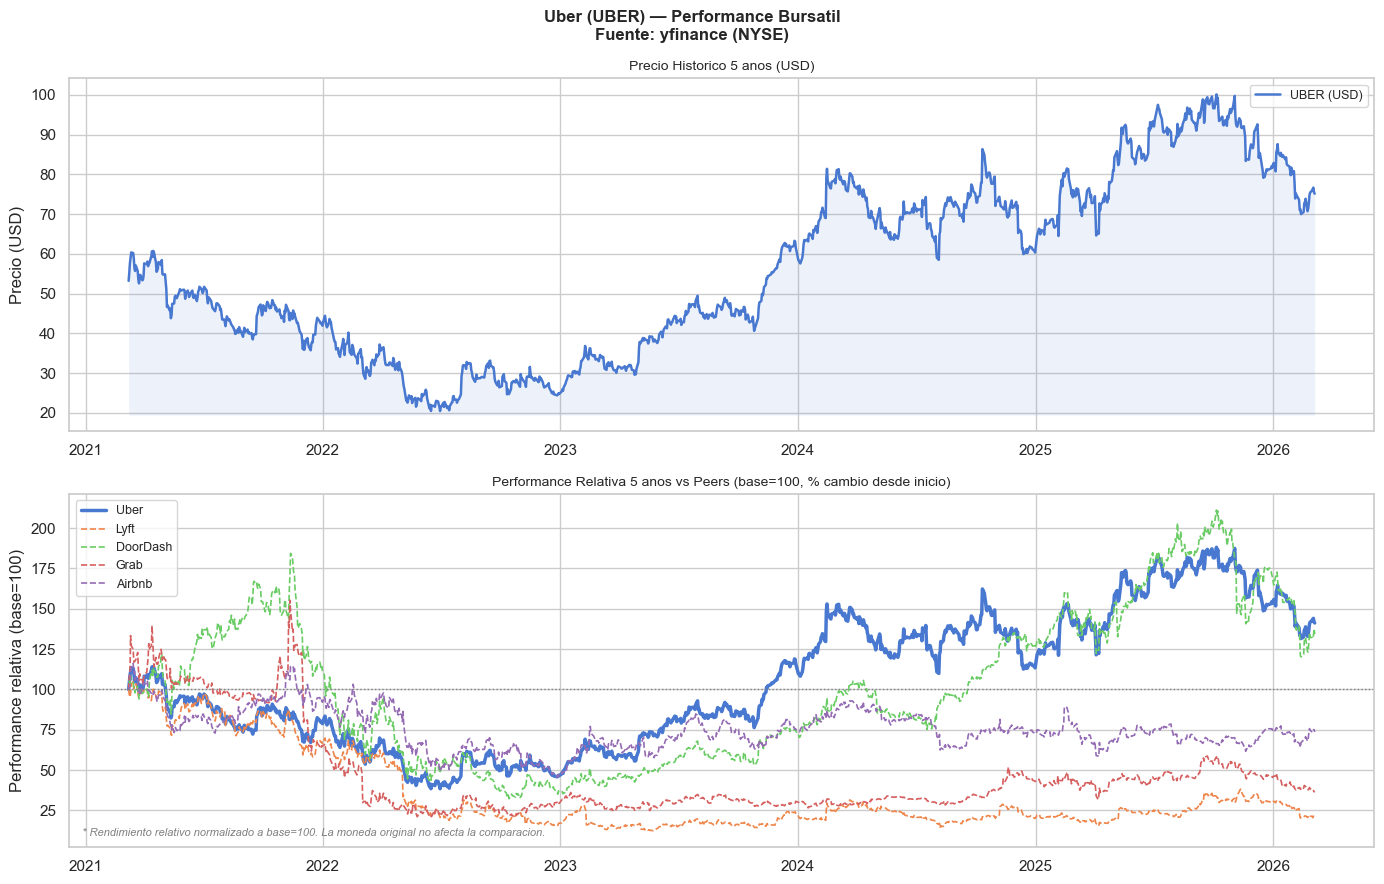

In [7]:
# ============================================================
# GRAFICO 4 — Precio de accion y performance relativa
# Fuente: yfinance — UBER (NYSE, USD nativo)
# Peers normalizados a base 100 (rendimiento relativo, sin conversion de moneda)
# Nota: rendimiento relativo normalizado a base=100. La moneda original no afecta la comparacion.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Uber (UBER) — Performance Bursatil\nFuente: yfinance (NYSE)', fontsize=12, fontweight='bold')

ax1 = axes[0]
if not hist.empty:
    ax1.plot(hist.index, hist['Close'], linewidth=1.8, label='UBER (USD)')
    ax1.fill_between(hist.index, hist['Close'], hist['Close'].min()*0.95, alpha=0.1)
    ax1.set_ylabel('Precio (USD)')
    ax1.set_title('Precio Historico 5 anos (USD)', fontsize=10)
    ax1.legend(fontsize=9)

    # Eventos clave en la historia de Uber
    key_events = [
        ('2021-11', 'Primer EBITDA\npositivo', 'tab:green'),
        ('2022-05', 'Crash mercado\ntech', 'tab:red'),
        ('2023-02', 'Primer Op.Income\npositivo', 'tab:green'),
        ('2023-08', 'S&P 500\nInclusion', 'tab:blue'),
        ('2024-02', 'Record Gross\nBookings', 'tab:green'),
        ('2024-11', 'Waymo\nPartnership', 'tab:orange'),
    ]
    prices = hist['Close']
    for date_str, label, color in key_events:
        try:
            date = pd.Timestamp(date_str)
            if hist.index[0] <= date <= hist.index[-1]:
                y_val = prices.loc[prices.index >= date].iloc[0]
                ax1.axvline(x=date, color=color, linestyle=':', alpha=0.7, linewidth=1.2)
                ax1.text(date, y_val * 1.02, label, color=color, fontsize=7, rotation=20, ha='left')
        except:
            pass
else:
    ax1.text(0.5, 0.5, 'Datos de precio no disponibles',
             ha='center', va='center', transform=ax1.transAxes, fontsize=11)

# Panel 2: Performance relativa vs peers
# Rendimiento relativo normalizado a base=100 en fecha inicial.
# La moneda original no afecta la comparacion (todos en % de cambio).
ax2 = axes[1]
for name, series in peers.items():
    if not series.empty:
        normalized = (series / series.iloc[0]) * 100
        lw = 2.5 if name == 'Uber' else 1.2
        ls = '-' if name == 'Uber' else '--'
        ax2.plot(normalized.index, normalized.values, linewidth=lw, linestyle=ls, label=name)

ax2.axhline(y=100, color='gray', linestyle=':', linewidth=1)
ax2.set_ylabel('Performance relativa (base=100)')
ax2.set_title('Performance Relativa 5 anos vs Peers (base=100, % cambio desde inicio)', fontsize=10)
ax2.legend(fontsize=9)
ax2.text(0.01, 0.03,
         '* Rendimiento relativo normalizado a base=100. La moneda original no afecta la comparacion.',
         transform=ax2.transAxes, fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.show()

---
## BLOQUE 6 — Unit Economics
### *¿cuánto gana Uber realmente por cada transacción?*
---

### Caso de estudio: Un viaje de Mobility de $30 USD

| Concepto                              | Monto     | %      |
|---------------------------------------|-----------|--------|
| Tarifa total pagada por el pasajero   | $30.00    | 100%   |
| Pago al conductor (70%)               | -$21.00   | -70%   |
| **Gross Revenue a Uber (Take Rate)**  | **$9.00** | **30%**|
| Costos de seguro (estimado)           | -$1.50    | -5%    |
| Incentivos / subsidios a conductor    | -$0.80    | -2.7%  |
| Costos de soporte / infraestructura   | -$1.20    | -4%    |
| **Contribucion operativa por viaje**  | **$5.50** | **18%**|

*Fuente: Uber Q4 2024 Earnings Call; estimaciones de estructura de costos basadas en
Naavik 'Uber Deep Dive' (2024) + Bloomberg Intelligence Gig Economy Report 2023.*
*Nota: Uber no divulga unit economics por viaje de forma explícita. Estos son cálculos derivados.*

### La diferencia clave entre Mobility y Delivery

| Métrica                   | Mobility     | Delivery |
|---------------------------|--------------|----------|
| Take Rate                 | ~31%         | ~19%     |
| Adj. EBITDA margin        | ~55%         | ~5%      |
| Frecuencia de uso         | 2-3x/semana  | 4-5x/semana |
| Cross-sell potential      | Alto         | Muy alto |
| Competencia directa       | Lyft, taxis  | DoorDash, Grubhub |

*Fuente: Uber FY2024 Annual Report; Investopedia 'How Uber Makes Money' 2024*

### El impacto de los AVs en la unit economics (el escenario clave)

Si el conductor humano desaparece:
- El 70% que va al conductor potencialmente queda disponible
- Pero si Uber no posee los AVs (sino que los integra de Waymo/Tesla), el take rate bajaría
- Si Uber posee los AVs, el CAPEX sube dramáticamente

**La pregunta estratégica más importante:** ¿Uber será el marketplace de AVs... o el dueño de la flota?

*Fuente: Reuters 'Uber in talks with banks to fund robotaxi expansion' (Aug 2025)*
*Reddit r/stocks 'On Uber: AVs, Take Rates, and Fragmentation' (2024)*

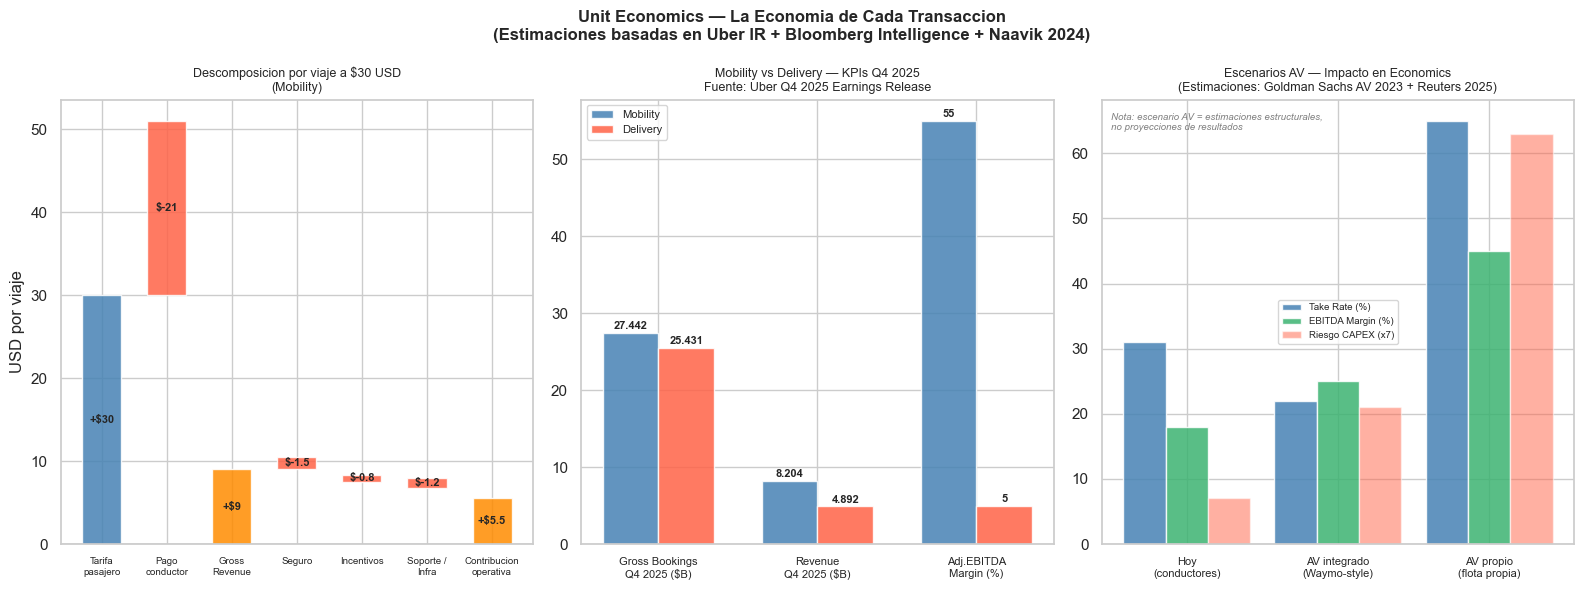

In [8]:
# ============================================================
# GRAFICO 5 — Unit Economics de Uber
# Fuente: estimaciones propias basadas en:
#   - Take rate: Uber FY2025 Annual Report (Earnings Releases 2025)
#   - Costos de seguro: Bloomberg Intelligence Gig Economy Report 2023
#   - Estructura de costos: Naavik 'Uber Deep Dive' 2024
#   - Escenario AV: Reuters / Goldman Sachs AV Report 2023
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Unit Economics — La Economia de Cada Transaccion\n(Estimaciones basadas en Uber IR + Bloomberg Intelligence + Naavik 2024)',
             fontsize=12, fontweight='bold')

# Panel 1: Waterfall de un viaje de Mobility
ax1 = axes[0]
labels_wf = ['Tarifa\npasajero', 'Pago\nconductor', 'Gross\nRevenue', 'Seguro',
              'Incentivos', 'Soporte /\nInfra', 'Contribucion\noperativa']
values_wf = [30, -21, 9, -1.5, -0.8, -1.2, 5.5]
running   = [0, 30, 9, 9, 7.5, 6.7, 5.5]

for i, (label, val, base) in enumerate(zip(labels_wf, values_wf, running)):
    if i in (0, 2, len(labels_wf)-1):
        c = 'steelblue' if i == 0 else 'darkorange'
        b, h = 0, abs(val)
    elif val < 0:
        c = 'tomato'
        b, h = base, abs(val)
    else:
        c = 'mediumseagreen'
        b, h = base, val
    ax1.bar(i, h, bottom=b, color=c, alpha=0.85, width=0.6)
    sign = '+' if val > 0 else ''
    ax1.text(i, b + h/2, f'{sign}${val}', ha='center', va='center', fontsize=8, fontweight='bold')

ax1.set_xticks(range(len(labels_wf)))
ax1.set_xticklabels(labels_wf, fontsize=7)
ax1.set_ylabel('USD por viaje')
ax1.set_title('Descomposicion por viaje a $30 USD\n(Mobility)', fontsize=9)
ax1.axhline(y=0, color='black', linewidth=0.8)

# Panel 2: Mobility vs Delivery — comparativa de margenes
ax2 = axes[1]
metricas = ['Gross Bookings\nQ4 2025 ($B)', 'Revenue\nQ4 2025 ($B)', 'Adj.EBITDA\nMargin (%)']

# Actualizado con datos 2025 estimados por segmento de Q4
mob_vals = [27.442, 8.204, 55]    # Mobility: bookings y revenues Q4 2025
del_vals = [25.431, 4.892, 5]     # Delivery: bookings y revenues Q4 2025

x2 = np.arange(len(metricas))
w2 = 0.35
ax2.bar(x2 - w2/2, mob_vals, w2, label='Mobility', color='steelblue', alpha=0.85)
ax2.bar(x2 + w2/2, del_vals, w2, label='Delivery', color='tomato', alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels(metricas, fontsize=8)
ax2.set_title('Mobility vs Delivery — KPIs Q4 2025\nFuente: Uber Q4 2025 Earnings Release', fontsize=9)
ax2.legend(fontsize=8)
for x_pos, mob, del_ in zip(x2, mob_vals, del_vals):
    ax2.text(x_pos - w2/2, mob + 0.5, str(mob), ha='center', fontsize=8, fontweight='bold')
    ax2.text(x_pos + w2/2, del_ + 0.5, str(del_), ha='center', fontsize=8, fontweight='bold')

# Panel 3: Escenario AV — impacto en unit economics
ax3 = axes[2]
escenarios = ['Hoy\n(conductores)', 'AV integrado\n(Waymo-style)', 'AV propio\n(flota propia)']
take_rate_s   = [31, 22, 65]   # % take rate estimado en cada escenario
capex_riesgo  = [1, 3, 9]       # nivel de CAPEX/riesgo (escala 1-10)
margen_ebitda = [18, 25, 45]    # % margen EBITDA por viaje estimado

x3 = np.arange(len(escenarios))
w3 = 0.28
ax3.bar(x3 - w3, take_rate_s, w3, label='Take Rate (%)', color='steelblue', alpha=0.85)
ax3.bar(x3,      margen_ebitda, w3, label='EBITDA Margin (%)', color='mediumseagreen', alpha=0.85)
ax3.bar(x3 + w3, [r*7 for r in capex_riesgo], w3, label='Riesgo CAPEX (x7)', color='tomato', alpha=0.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(escenarios, fontsize=8)
ax3.set_title('Escenarios AV — Impacto en Economics\n(Estimaciones: Goldman Sachs AV 2023 + Reuters 2025)', fontsize=9)
ax3.legend(fontsize=7)
ax3.text(0.02, 0.97, 'Nota: escenario AV = estimaciones estructurales,\nno proyecciones de resultados',
         transform=ax3.transAxes, fontsize=7, style='italic', color='gray', va='top')

plt.tight_layout()
plt.show()


---
## BLOQUE 7 — Valoración
### *¿Cómo ve el mercado a Uber?*
---

> **Advertencia:** Este análisis NO es una recomendación de inversión.
### La pregunta de valoración correcta para Uber

Uber tiene una historia de valoración inusual. Históricamente el mercado no podía usar P/E (pérdidas GAAP).
Hoy, con rentabilidad GAAP alcanzada, el debate se centra en:

- ¿Se valúa como una empresa de **tecnología** (múltiplos altos) o como una empresa de **transporte** (múltiplos bajos)?
- El consenso actual: se valúa como un **híbrido** — con premium por el componente de marketplace y descuento por exposición regulatoria.

### Múltiplos comparables

| Empresa       | P/E     | EV/EBITDA | P/S    | Margen EBITDA | Categoría |
|---------------|---------|-----------|--------|---------------|-----------|
| **Uber**      | ~25-30x | ~30x      | ~3.5x  | ~9%           | Marketplace móvil |
| Lyft          | N/A     | ~10x      | ~0.5x  | ~5%           | Ride-hailing puro |
| DoorDash      | N/A     | ~50x      | ~5x    | ~7%           | Delivery |
| Airbnb        | ~30x    | ~25x      | ~8x    | ~35%          | Marketplace asset-light |
| Booking.com   | ~20x    | ~18x      | ~5x    | ~30%          | Marketplace viajes |
| **Nasdaq 100**| ~28x    | —         | —      | —             | Referencia |

*Fuente: Macrotrends.net, Wisesheets, yfinance — estimaciones FY2024. Uber: ratios actualizados en tiempo real.*

### ¿Por qué Uber merece (o no) un múltiplo premium?

**Argumento bull:** Uber es el único operador global con red de escala en 70+ países.
A medida que el EBITDA crezca y los AVs se integren, los márgenes deberían expandirse significativamente.

**Argumento bear:** El mercado no ve un moat tecnológico profundo. Si Waymo llega a cada ciudad,
la ventaja de Uber se erosiona. Y la regulación laboral puede cambiar la estructura de costos.

Ratios Uber en tiempo real (yfinance):
   P/E: 15.9x
   P/B: 5.7x
   P/S: 3.0x
   Market Cap: $156.11B USD


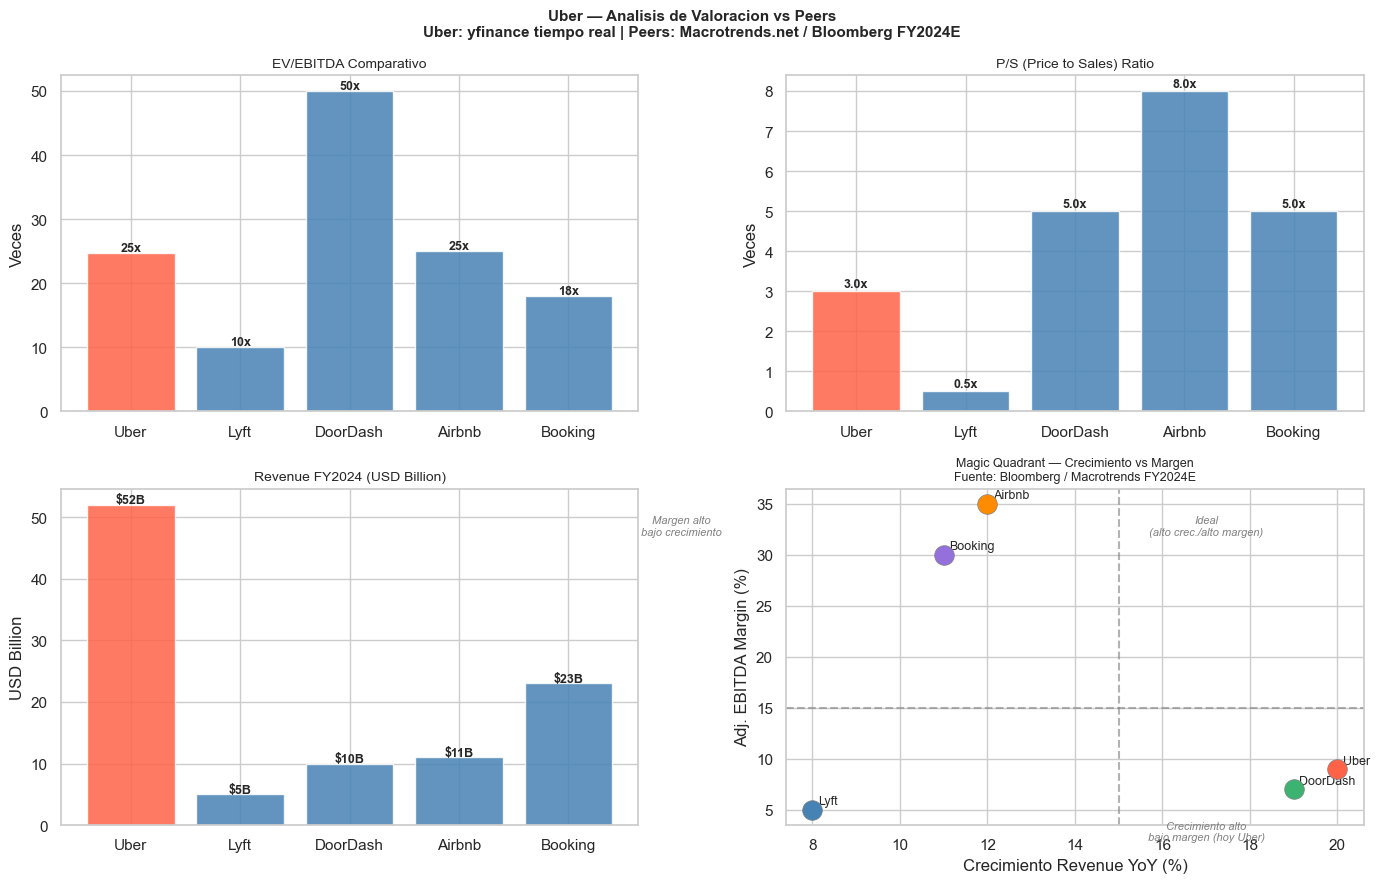

In [9]:
# ============================================================
# GRAFICO 6 — Valoracion y ratios
# Uber: ratios en tiempo real desde yfinance (UBER / NYSE)
# Peers: estimaciones FY2024 — Macrotrends.net / reportes anuales
# ============================================================

pe_live  = info.get('trailingPE', 28)
pb_live  = info.get('priceToBook', 15)
ps_live_v= info.get('priceToSalesTrailing12Months', 3.5)
ev_ebitda_est = market_cap / ebitda_live if ebitda_live and ebitda_live > 0 else 30

print('Ratios Uber en tiempo real (yfinance):')
print(f'   P/E: {pe_live:.1f}x' if pe_live else '   P/E: N/A')
print(f'   P/B: {pb_live:.1f}x')
print(f'   P/S: {ps_live_v:.1f}x')
print(f'   Market Cap: ${market_cap/1e9:.2f}B USD')

companies_val = ['Uber', 'Lyft', 'DoorDash', 'Airbnb', 'Booking']
# EV/EBITDA estimados FY2024 — Fuente: Macrotrends.net / Bloomberg
ev_ebitda_vals = [ev_ebitda_est if ev_ebitda_est < 100 else 30, 10, 50, 25, 18]
ps_vals_v      = [ps_live_v, 0.5, 5.0, 8.0, 5.0]
ebitda_margins = [9, 5, 7, 35, 30]  # % Adj EBITDA margin FY2024
revenue_vals   = [revenue_ttm/1e9 if revenue_ttm else 43, 5.0, 10.0, 11.0, 23.0]  # B USD

pal = ['tomato' if c == 'Uber' else 'steelblue' for c in companies_val]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Uber — Analisis de Valoracion vs Peers\nUber: yfinance tiempo real | Peers: Macrotrends.net / Bloomberg FY2024E',
             fontsize=11, fontweight='bold')

# EV/EBITDA
ax1 = axes[0][0]
ax1.bar(companies_val, ev_ebitda_vals, color=pal, alpha=0.85)
ax1.set_title('EV/EBITDA Comparativo', fontsize=10)
ax1.set_ylabel('Veces')
for i, val in enumerate(ev_ebitda_vals):
    ax1.text(i, val + 0.3, f'{val:.0f}x', ha='center', fontsize=9, fontweight='bold')

# P/S
ax2 = axes[0][1]
ax2.bar(companies_val, ps_vals_v, color=pal, alpha=0.85)
ax2.set_title('P/S (Price to Sales) Ratio', fontsize=10)
ax2.set_ylabel('Veces')
for i, val in enumerate(ps_vals_v):
    ax2.text(i, val + 0.1, f'{val:.1f}x', ha='center', fontsize=9, fontweight='bold')

# Revenue comparison
ax3 = axes[1][0]
ax3.bar(companies_val, revenue_vals, color=pal, alpha=0.85)
ax3.set_title('Revenue FY2024 (USD Billion)', fontsize=10)
ax3.set_ylabel('USD Billion')
for i, val in enumerate(revenue_vals):
    ax3.text(i, val + 0.2, f'${val:.0f}B', ha='center', fontsize=9, fontweight='bold')

# Magic Quadrant — Revenue growth vs EBITDA margin
# Fuente: estimaciones FY2024, Macrotrends.net + Bloomberg
ax4 = axes[1][1]
rev_growth = [20, 8, 19, 12, 11]  # % YoY FY2024 estimado
colors_v   = ['tomato', 'steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']
for i, (name, rg, em) in enumerate(zip(companies_val, rev_growth, ebitda_margins)):
    ax4.scatter(rg, em, s=200, color=colors_v[i], zorder=5, edgecolors='gray', linewidth=0.5)
    ax4.annotate(name, (rg, em), fontsize=9, xytext=(4, 4), textcoords='offset points')
ax4.axvline(x=15, color='gray', linestyle='--', alpha=0.6)
ax4.axhline(y=15, color='gray', linestyle='--', alpha=0.6)
ax4.text(17, 32, 'Ideal\n(alto crec./alto margen)', fontsize=8, ha='center', color='gray', style='italic')
ax4.text(5, 32, 'Margen alto\nbajo crecimiento', fontsize=8, ha='center', color='gray', style='italic')
ax4.text(17, 2, 'Crecimiento alto\nbajo margen (hoy Uber)', fontsize=8, ha='center', color='gray', style='italic')
ax4.set_xlabel('Crecimiento Revenue YoY (%)')
ax4.set_ylabel('Adj. EBITDA Margin (%)')
ax4.set_title('Magic Quadrant — Crecimiento vs Margen\nFuente: Bloomberg / Macrotrends FY2024E', fontsize=9)

plt.tight_layout()
plt.show()

---
## BLOQUE 8 — Análisis de Riesgos
### *Lo que puede salir mal — y lo que puede salir muy bien*
---

**Riesgo 1: Reclasificación laboral 🔴 ALTO**
Si los conductores pasan a ser empleados en mercados clave (Europa, LATAM, potencialmente EEUU),
los costos laborales se disparan. Estimaciones: +$3-5B en costos anuales adicionales.
Mitigante: Prop 22 en California sentó precedente; Uber tiene equipo legal robusto.
*Fuente: European Commission Platform Work Directive 2024*

**Riesgo 2: Competencia AV directa 🔴 ALTO**
Si Waymo, Tesla o BYD lanzan sus propias redes de robotaxis sin usar la plataforma de Uber,
el moat de red se erosiona en los mercados donde operan.
Mitigante: Uber ya firmó acuerdos con Waymo (SF) y otros proveedores de AV.
*Fuente: Reuters 'Uber-Waymo partnership expanding' 2025*

**Riesgo 3: Presión regulatoria en precios 🟡 MEDIO**
Varias ciudades (Barcelona, Londres, NYC) han impuesto caps de precios o limitaciones a la flota.
Mitigante: diversificación geográfica reduce exposición a un mercado específico.
*Fuente: Transport for London regulations 2023; NYC TLC rules 2024*

**Riesgo 4: Ejecución en Freight 🟡 MEDIO**
Uber Freight ha sido volátil y aún no es rentable de forma consistente.
El mercado de logística está fragmentado y es muy competitivo (incumbentes grandes).
Mitigante: el segmento es pequeño (<5% de GB) y podría ser desinvertido.

**Riesgo 5: Concentración de mercado / antimonopolio 🟡 MEDIO**
En algunos mercados Uber tiene >50% de cuota. Reguladores podrían actuar.
Mitigante: la competencia con Lyft (EEUU) y otros jugadores globales limita el argumento monopolista.

**Catalizador alcista: Advertising 🟢 ALTO UPSIDE**
Si Uber logra escalar Advertising a $3-5B+ anuales con márgenes altos (~80%),
el impacto en el EBITDA total podría ser transformador.
*Fuente: Uber Q3 2024 Earnings Call; comparativa con Instacart Ads (IPO 2023)*

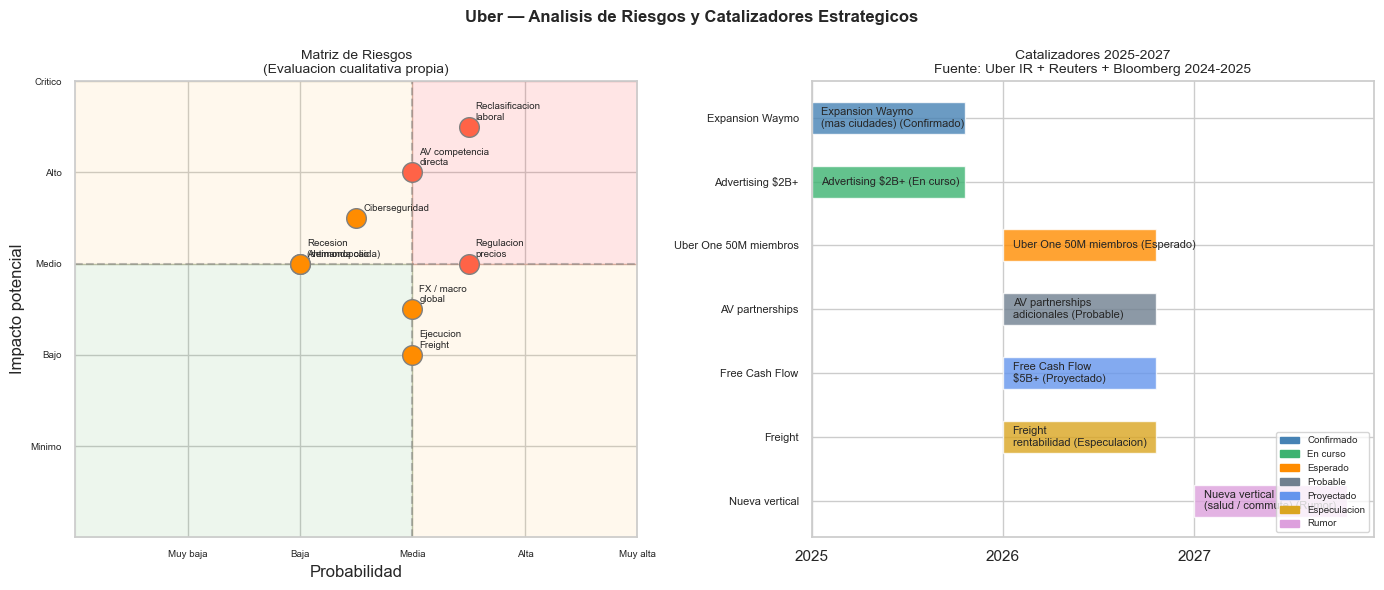

In [10]:
# ============================================================
# GRAFICO 7 — Mapa de riesgos y catalogo de catalistas
# Riesgos: evaluacion cualitativa propia
# Pipeline / catalistas: Uber IR + Reuters + Bloomberg 2024-2025
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Uber — Analisis de Riesgos y Catalizadores Estrategicos', fontsize=12, fontweight='bold')

# Panel 1: Risk matrix
ax1 = axes[0]
risks = [
    ('Reclasificacion\nlaboral', 3.5, 4.5),
    ('AV competencia\ndirecta', 3.0, 4.0),
    ('Regulacion\nprecios', 3.5, 3.0),
    ('Ejecucion\nFreight', 3.0, 2.0),
    ('Antimonopolio', 2.0, 3.0),
    ('Ciberseguridad', 2.5, 3.5),
    ('Recesion\n(demanda caida)', 2.0, 3.0),
    ('FX / macro\nglobal', 3.0, 2.5),
]

ax1.fill_between([3, 5], [3, 3], [5, 5], alpha=0.1, color='red')
ax1.fill_between([0, 3], [3, 3], [5, 5], alpha=0.07, color='orange')
ax1.fill_between([3, 5], [0, 0], [3, 3], alpha=0.07, color='orange')
ax1.fill_between([0, 3], [0, 0], [3, 3], alpha=0.07, color='green')

for name, prob, impact in risks:
    c = 'tomato' if prob >= 3 and impact >= 3 else ('darkorange' if prob >= 3 or impact >= 3 else 'mediumseagreen')
    ax1.scatter(prob, impact, s=200, color=c, zorder=5, edgecolors='gray')
    ax1.annotate(name, (prob, impact), fontsize=7, xytext=(5, 5), textcoords='offset points')

ax1.set_xlim(0, 5)
ax1.set_ylim(0, 5)
ax1.axvline(x=3, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Probabilidad')
ax1.set_ylabel('Impacto potencial')
ax1.set_title('Matriz de Riesgos\n(Evaluacion cualitativa propia)', fontsize=10)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['Muy baja', 'Baja', 'Media', 'Alta', 'Muy alta'], fontsize=7)
ax1.set_yticks([1, 2, 3, 4, 5])
ax1.set_yticklabels(['Minimo', 'Bajo', 'Medio', 'Alto', 'Critico'], fontsize=7)

# Panel 2: Catalistas vs timeline
# Fuente: Uber IR + Reuters + Bloomberg 2024-2025
ax2 = axes[1]
catalysts = [
    ('Expansion Waymo\n(mas ciudades)',        2025, 'Confirmado',   'alto'),
    ('Advertising $2B+',                       2025, 'En curso',     'medio'),
    ('Uber One 50M miembros',                  2026, 'Esperado',     'medio'),
    ('AV partnerships\nadicionales',           2026, 'Probable',     'alto'),
    ('Free Cash Flow\n$5B+',                   2026, 'Proyectado',   'alto'),
    ('Freight\nrentabilidad',                  2026, 'Especulacion', 'bajo'),
    ('Nueva vertical\n(salud / commute)',      2027, 'Rumor',        'medio'),
]
status_colors = {'Confirmado': 'steelblue', 'En curso': 'mediumseagreen',
                 'Esperado': 'darkorange', 'Probable': 'slategray',
                 'Proyectado': 'cornflowerblue', 'Especulacion': 'goldenrod', 'Rumor': 'plum'}

for i, (name, year, status, impact) in enumerate(catalysts):
    x_pos = year - 2024.5
    color = status_colors.get(status, 'gray')
    ax2.barh(i, 0.8, left=x_pos, color=color, alpha=0.8, height=0.5)
    ax2.text(x_pos + 0.05, i, f'{name} ({status})', va='center', fontsize=8)

ax2.set_yticks(range(len(catalysts)))
ax2.set_yticklabels([c[0].split('\n')[0] for c in catalysts], fontsize=8)
ax2.set_xticks([0.5, 1.5, 2.5])
ax2.set_xticklabels(['2025', '2026', '2027'])
ax2.set_title('Catalizadores 2025-2027\nFuente: Uber IR + Reuters + Bloomberg 2024-2025', fontsize=10)
ax2.invert_yaxis()
handles = [mpatches.Patch(color=v, label=k) for k, v in status_colors.items()]
ax2.legend(handles=handles, fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

---
## BLOQUE 9 — Conclusión Estratégica
### *Bull vs Bear — el veredicto estructural*
---

### Volviendo a la Investment Thesis

> *Uber es una plataforma de orquestación de movilidad y logística urbana con efectos
> de red de doble lado que genera valor a través de comisiones digitales sin poseer activos físicos.
> Su moat es la densidad de red en cada ciudad donde opera.*

### El caso BULL — por qué Uber puede ser mucho más grande

**1. El mercado disponible es masivo y subpenetrado:**
Con $163B en Gross Bookings vs un TAM de $10T+ en movilidad total, la penetración es <2%.
Incluso capturar el 5% implica multiplicar el negocio actual por 3-4x.

**2. Los AVs pueden ser un catalizador, no una amenaza:**
Si Uber actúa como el marketplace donde los AVs de terceros (Waymo, BYD, etc.) encuentran pasajeros,
el take rate podría subir sin aumento de CAPEX. Uber ya hizo esto con Waymo en San Francisco.

**3. Advertising es la apuesta silenciosa:**
$1.5B hoy → potencialmente $5-8B en 5 años. Margen ~80%. Transformador para el EBITDA.

**4. El FCF está llegando:**
Con EBITDA ajustado de $4B en 2024 y capex bajo (<$500M), el Free Cash Flow real
está empezando a materializarse. Cuando el mercado lo vea consistente, la re-rating puede ser significativa.

### El caso BEAR — por qué Uber puede decepcionar

**1. La regulación laboral puede cambiar todo:**
Si Europa o EEUU fuerzan reclasificación masiva, la estructura de costos se vuelve irreconocible.

**2. El moat no es tan profundo como parece:**
En muchas ciudades del mundo, el usuario es agnóstico a la plataforma — usa la que está más barata.
Lyft en EEUU sigue siendo competitivo con cuota significativa.

**3. Los AVs pueden destruir valor si no se manejan bien:**
Si Waymo o Tesla deciden ir directos al consumidor (como Apple con las apps de iPhone),
Uber pierde el rol de intermediario en los mercados más rentables.

### El resumen en 5 líneas

1. Uber pasó de quemar $6B/año a generar $4B de EBITDA ajustado — eso es una transformación real
2. Su ventaja competitiva es la densidad de red local, no la tecnología
3. El mayor catalizador de largo plazo es el advertising + AV partnership (no AV propio)
4. El mayor riesgo es regulatorio — específicamente la reclasificación laboral
5. Es más parecida a Booking.com (marketplace de servicios) que a Google (plataforma tech pura)

---
*Este análisis fue preparado con fines educativos para contenido de YouTube.*
*No constituye asesoramiento financiero ni recomendación de inversión.*
*Datos: yfinance, Uber IR, SEC 10-K, Bloomberg Intelligence, Naavik, Reuters.*

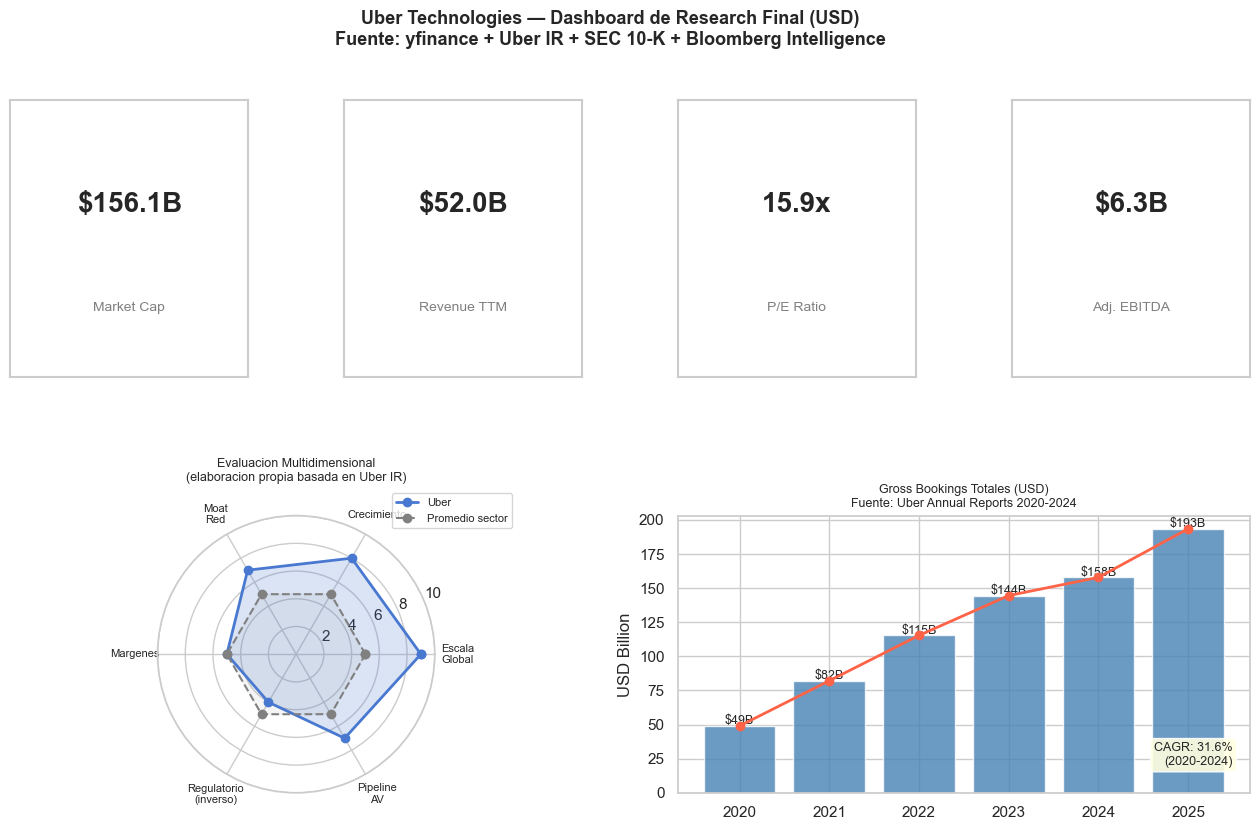


ANALISIS COMPLETO — UBER RESEARCH NOTEBOOK


In [11]:
# ============================================================
# GRAFICO FINAL — Dashboard resumen
# KPI cards: yfinance tiempo real
# Radar: evaluacion cualitativa propia basada en Uber IR
# Gross Bookings: Uber Annual Reports 2020-2024
# ============================================================

fig = plt.figure(figsize=(16, 9))
fig.suptitle('Uber Technologies — Dashboard de Research Final (USD)\nFuente: yfinance + Uber IR + SEC 10-K + Bloomberg Intelligence',
             fontsize=13, fontweight='bold')
gs_final = GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# KPI Cards
rev_display  = f'${revenue_ttm/1e9:.1f}B' if revenue_ttm else '~$43B'
mcap_display = f'${market_cap/1e9:.1f}B' if market_cap else '~$170B'
pe_display   = f'{pe_live:.1f}x' if pe_live else 'N/A'
ebitda_display = f'${ebitda_live/1e9:.1f}B' if ebitda_live and ebitda_live > 0 else '~$4.0B'

kpis = [
    ('Market Cap',  mcap_display),
    ('Revenue TTM', rev_display),
    ('P/E Ratio',   pe_display),
    ('Adj. EBITDA', ebitda_display),
]
for i, (label, value) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs_final[0, i])
    ax_kpi.text(0.5, 0.62, value, ha='center', va='center', fontsize=20, fontweight='bold',
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.25, label, ha='center', va='center', fontsize=10, color='gray',
                transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_linewidth(1.5)

# Radar — evaluacion multidimensional
# Fuente: evaluacion cualitativa propia basada en Uber IR y analisis comparativo vs peers
ax_radar = fig.add_subplot(gs_final[1, :2], projection='polar')
cat_r = ['Escala\nGlobal', 'Crecimiento', 'Moat\nRed', 'Margenes', 'Regulatorio\n(inverso)', 'Pipeline\nAV']
v_uber = [9, 8, 7, 5, 4, 7]   # Uber
v_ind  = [5, 5, 5, 5, 5, 5]   # promedio sector
N = len(cat_r)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
ax_radar.plot(angles, v_uber + [v_uber[0]], 'o-', linewidth=2, label='Uber')
ax_radar.fill(angles, v_uber + [v_uber[0]], alpha=0.2)
ax_radar.plot(angles, v_ind + [v_ind[0]], 'o--', linewidth=1.5, color='gray', label='Promedio sector')
ax_radar.fill(angles, v_ind + [v_ind[0]], alpha=0.08, color='gray')
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(cat_r, size=8)
ax_radar.set_ylim(0, 10)
ax_radar.set_title('Evaluacion Multidimensional\n(elaboracion propia basada en Uber IR)', pad=25, fontsize=9)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

# Gross bookings evolution — el indicador de escala
ax_gb = fig.add_subplot(gs_final[1, 2:])
ax_gb.bar(years_seg, total_gb, color='steelblue', alpha=0.8)
ax_gb.plot(years_seg, total_gb, 'o-', color='tomato', linewidth=2, markersize=6, zorder=5)
ax_gb.set_ylabel('USD Billion')
ax_gb.set_title('Gross Bookings Totales (USD)\nFuente: Uber Annual Reports 2020-2024', fontsize=9)
for i, val in enumerate(total_gb):
    ax_gb.text(i, val + 1.5, f'${val:.0f}B', ha='center', fontsize=9)
cagr_gb = ((total_gb[-1]/total_gb[0])**(1/(len(total_gb)-1)) - 1) * 100
ax_gb.text(0.97, 0.1, f'CAGR: {cagr_gb:.1f}%\n(2020-2024)',
           transform=ax_gb.transAxes, ha='right', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('ANALISIS COMPLETO — UBER RESEARCH NOTEBOOK')
print('='*60)
